<a href="https://colab.research.google.com/github/adityapri/Neural-Network---Classification/blob/main/P2_pytorch_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Neural Network Classification Using PyTorch

In [41]:
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state=42)

In [26]:
import pandas as pd

circles = pd.DataFrame({"X1": X[:,0],
                        "X2": X[:,1],
                        "labels": y})
circles.head(5)

,X1,X2,labels
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [19]:
circles.labels.value_counts()

,count
labels,
1,500
0,500


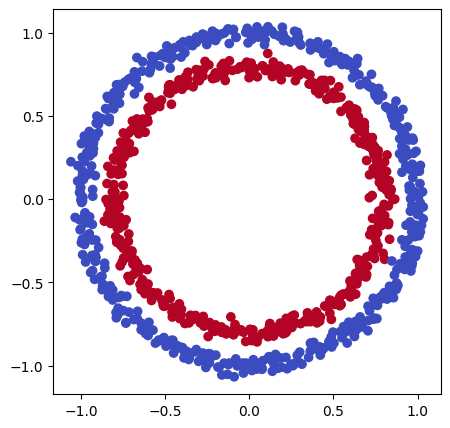

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap='coolwarm')

In [42]:
#Turning data into tensors
import torch

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [45]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [50]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [53]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

In [54]:
# Set device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [56]:
# Constructing a Model by subclassing nn.Module
from torch import nn
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,out_features=10)
    self.layer_2 = nn.Linear(in_features=10,out_features=1)

  def forward(self, x):
    return self.layer_2(self.layer_1(x))

model_0 = CircleModelV0()
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=1, bias=True)
)

In [57]:
# Replicate model_0 using nn.Sequential()

model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=1, bias=True)
)

In [58]:
untrained_preds = model_0(X_train)
print(f"First 5 predictions: {untrained_preds[:5]}")
print(f"First 5 Actuals: {y_test[:5]}")

First 5 predictions: tensor([[-0.2374],
        [-0.2531],
        [-0.4976],
        [-0.4950],
        [-0.3197]], grad_fn=<SliceBackward0>)
First 5 Actuals: tensor([1., 0., 1., 0., 1.])


In [60]:
# Set up loss function and optimizers
# create a loss function
loss_fn = nn.BCEWithLogitsLoss()

# create an optimizer
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr=0.01)

In [70]:
# let's also create an evaluation metric, accuracy function

def accuracy_fn(y_true,y_preds):
  correct = torch.eq(y_true,y_preds).sum().item()
  # print(correct)
  return (correct/len(y_preds))*100




In [71]:
# let's see what comes out of the model during forward pass
y_logits = model_0(X_test.to(device)[:5])
y_logits

tensor([[-0.3590],
        [-0.2829],
        [-0.4553],
        [-0.3321],
        [-0.2913]], grad_fn=<AddmmBackward0>)

In [72]:
# use sigmoid on the logits -> prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4112],
        [0.4298],
        [0.3881],
        [0.4177],
        [0.4277]], grad_fn=<SigmoidBackward0>)

In [77]:
# prediction probabilities -> prediction labels
y_labels = torch.round(y_pred_probs)
y_labels

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], grad_fn=<RoundBackward0>)

In [79]:
# Building a training and testing loop
torch.manual_seed(42)

epochs = 100

# put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  ### training
  model_0.train()

  ##Forward Pass
  y_logits = model_0(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  ##loss calculation
  loss = loss_fn(y_logits,
                 y_train)

  acc = accuracy_fn(y_true=y_train,
                    y_preds=y_preds)

  ##Optimizer zero grad
  optimizer.zero_grad()

  ##backward loss
  loss.backward()

  ##Update params, using SGD
  optimizer.step()

  ###Testing
  model_0.eval()

  with torch.inference_mode():
    ## Forward pass
    test_logits = model_0(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))
    ## Loss, Accuracy
    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_preds=test_preds)

  #### Print out what's happening every 10 epochs
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")



Epoch: 0 | Loss: 0.70729, Accuracy: 50.00% | Test loss: 0.71000, Test Accuracy: 50.00%
Epoch: 10 | Loss: 0.70561, Accuracy: 50.00% | Test loss: 0.70845, Test Accuracy: 50.00%
Epoch: 20 | Loss: 0.70413, Accuracy: 50.00% | Test loss: 0.70711, Test Accuracy: 50.00%
Epoch: 30 | Loss: 0.70285, Accuracy: 50.00% | Test loss: 0.70594, Test Accuracy: 50.00%
Epoch: 40 | Loss: 0.70172, Accuracy: 50.00% | Test loss: 0.70493, Test Accuracy: 50.00%
Epoch: 50 | Loss: 0.70074, Accuracy: 50.00% | Test loss: 0.70404, Test Accuracy: 50.00%
Epoch: 60 | Loss: 0.69989, Accuracy: 50.00% | Test loss: 0.70327, Test Accuracy: 50.00%
Epoch: 70 | Loss: 0.69914, Accuracy: 50.00% | Test loss: 0.70260, Test Accuracy: 50.00%
Epoch: 80 | Loss: 0.69848, Accuracy: 50.00% | Test loss: 0.70201, Test Accuracy: 50.00%
Epoch: 90 | Loss: 0.69791, Accuracy: 49.00% | Test loss: 0.70149, Test Accuracy: 48.50%
